In [1]:
from loguru import logger
from transformers import BartForConditionalGeneration, BertForSequenceClassification
from os.path import join


from carl.inference_components.conditional_low_level_policy import (
    ConditionalLowLevelPolicy,
    TransformerConditionalLowLevelPolicy,
)
from carl.inference_components.subgoal_generator import (
    TransformerSubgoalGenerator,
)
from carl.inference_components.value import TransformerValue, Value


logger.info('testing solve components')

2025-06-08 04:18:44.475 | INFO     | __main__:<module>:16 - testing solve components


In [2]:
components_prefix = './rl-data/validation/sokoban/components/full_data/'

path_to_policy_weights: str = join(components_prefix, 'policy/checkpoint-94820')
path_to_cllp_weights: str = join(components_prefix, 'cllp/8/checkpoint-167585')
path_to_value_function_weights: str = join(components_prefix, 'value/checkpoint-1343100')
path_to_generator_weights_k8: str = join(components_prefix, 'generator/border/8/checkpoint-75856')
path_to_generator_weights_k4: str = join(components_prefix, 'generator/border/4/checkpoint-75856')

In [3]:
from carl.environment.sokoban.env import SokobanEnv
from carl.environment.sokoban.tokenizer import SokobanTokenizer
import functools

env_tokenizer: SokobanTokenizer = SokobanTokenizer()
env_class = functools.partial(SokobanEnv, tokenizer=env_tokenizer)
env: SokobanEnv = env_class()

In [4]:
from transformers import BartConfig, BertConfig
from carl.inference_components.subgoal_generator import AdaptiveSubgoalGenerator

from carl.inference_components.validator import BasicValidator

subgoal_generation_kwargs: dict[str, int] = {
    'num_beams': 16,
    'num_return_sequences': 1,
    'max_new_tokens': 145,
}

subgoal_generator_cls = functools.partial(
    TransformerSubgoalGenerator, generator_network_class=BartForConditionalGeneration.from_pretrained
)

adaptive_subgoal_generator = AdaptiveSubgoalGenerator(
    generator_k_list=[8, 4],
    subgoal_generator_class=subgoal_generator_cls,
    paths_to_generator_weights=[path_to_generator_weights_k8, path_to_generator_weights_k4],
    env=env,
    subgoal_generation_kwargs=subgoal_generation_kwargs,
)

adaptive_subgoal_generator.construct_network()


value_function: Value = TransformerValue(
    value_network_class=BertForSequenceClassification.from_pretrained,
    path_to_value_network_weights=path_to_value_function_weights,
    env=env,
    type_of_evaluation='regression',
)
value_function.construct_network()

cllp: ConditionalLowLevelPolicy = TransformerConditionalLowLevelPolicy(
    BertForSequenceClassification.from_pretrained, path_to_cllp_weights, env
)
cllp.construct_network()

validator = BasicValidator(env_class(), cllp, budget_for_achieving_subgoal=8)
validator.construct_network()

2025-06-08 04:18:44.553 | DEBUG    | carl.inference_components.component:instantiate_network:52 - Loading weights from ./rl-data/validation/sokoban/components/full_data/generator/border/8/checkpoint-75856
2025-06-08 04:18:44.556 | INFO     | carl.inference_components.component:instantiate_network:74 - Provided direct path to the ckpt


2025-06-08 04:18:45.227 | SUCCESS  | carl.inference_components.component:instantiate_network:86 - Loaded weights from ./rl-data/validation/sokoban/components/full_data/generator/border/8/checkpoint-75856
2025-06-08 04:18:45.233 | DEBUG    | carl.inference_components.component:instantiate_network:52 - Loading weights from ./rl-data/validation/sokoban/components/full_data/generator/border/4/checkpoint-75856
2025-06-08 04:18:45.234 | INFO     | carl.inference_components.component:instantiate_network:74 - Provided direct path to the ckpt
2025-06-08 04:18:45.802 | SUCCESS  | carl.inference_components.component:instantiate_network:86 - Loaded weights from ./rl-data/validation/sokoban/components/full_data/generator/border/4/checkpoint-75856
2025-06-08 04:18:46.688 | DEBUG    | carl.inference_components.component:instantiate_network:52 - Loading weights from ./rl-data/validation/sokoban/components/full_data/value/checkpoint-1343100
2025-06-08 04:18:46.689 | INFO     | carl.inference_components

In [5]:
import functools
from carl.solver.planners import AdasubsPlanner
from carl.solver.subgoal_search import Solver

AdasubsPlannerCls = functools.partial(AdasubsPlanner, generators_k_list=[8, 4])

solver = Solver(
    500,
    AdasubsPlannerCls,
    adaptive_subgoal_generator,
    validator,
    value_function,
)

In [6]:
from carl.environment.instance_generator import (
    BasicInstanceGenerator,
    GeneralIterableDataLoader,
)

path_to_folder_with_data = './rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35'

env = SokobanEnv(SokobanTokenizer(None, size_of_board=(12, 12)), num_boxes=4)
instance_generator = BasicInstanceGenerator(
    generator=GeneralIterableDataLoader(path_to_folder_with_data), batch_size=1
)

2025-06-08 04:18:47.402 | DEBUG    | carl.environment.instance_generator:__init__:35 - path: ./rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35


In [7]:
initial_state_loader = iter(instance_generator.reset_dataloader())
inputs = []
figs = []
for _ in range(2):
    initial_state = next(initial_state_loader).cpu().numpy()[0]
    inputs.append(initial_state)

2025-06-08 04:18:47.421 | DEBUG    | carl.environment.instance_generator:get_stream:54 - Found 1 files in ./rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35
2025-06-08 04:18:47.423 | INFO     | carl.environment.instance_generator:process_data:44 - Processing data from ./rl-data/validation/sokoban/progress/boards_1000_b4_gs25_c300_p0.35/boards_1000_b4_gs25_c300_p0.35.joblib


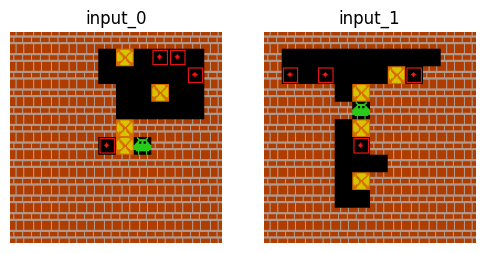

In [8]:
# Vizualize inputs
fig = env.many_states_to_repr(inputs, titles=['input_{}'.format(i) for i in range(len(inputs))])
display(fig)

# Sequential Solve

In [9]:
outputs_sequential = []
for i, input_board in enumerate(inputs):
    print('Solving board number', i)
    output = solver.solve(input_board)
    outputs_sequential.append(output)

Solving board number 0
Rising recursion limit for worker from 3000 to 2147483640.


2025-06-08 04:19:15.363 | SUCCESS  | carl.solver.subgoal_search:solve:109 - solved with 30 low level nodes visited


Solving board number 1


2025-06-08 04:22:06.294 | SUCCESS  | carl.solver.subgoal_search:solve:109 - solved with 159 low level nodes visited


In [10]:
# Logging Function

def display_solutions(outputs):
    figs = []
    for j, output in enumerate(outputs):
        solution, _ = output
        if solution['solved']:
            subgoals = solution['subgoal_path']
            titles = [
                f'subgoal[{i}]'
                for i in range(len(subgoals))
            ]
            
            fig = env.many_states_to_repr(subgoals, titles=titles)
        else:
            fig = env.state_to_repr(initial_state, title='initial_state (unsolved)')

        figs.append(fig)

    for fig in figs:
        display(fig)
        
display_solutions(outputs_sequential)

TypeError: cannot unpack non-iterable Experience object

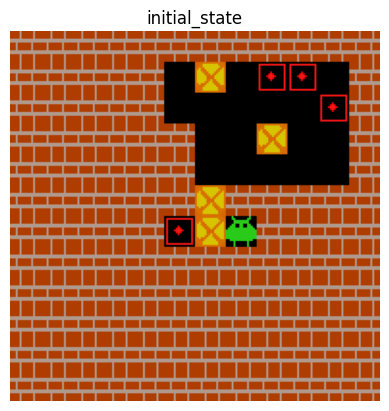

In [ ]:
initial_state = outputs_sequential[0][1]['search_tree'].state
env.state_to_repr(initial_state, title='initial_state')

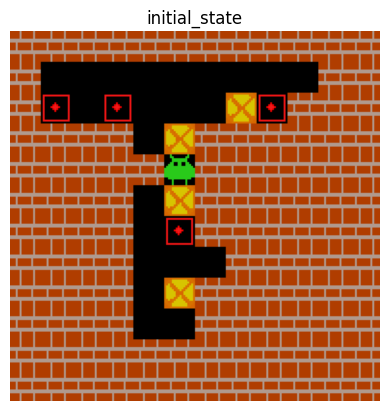

In [ ]:
initial_state = outputs_sequential[1][1]['search_tree'].state
env.state_to_repr(initial_state, title='initial_state')

In [ ]:
initial_node = initial_state = outputs_sequential[0][1]['search_tree']
initial_node.children[0].children

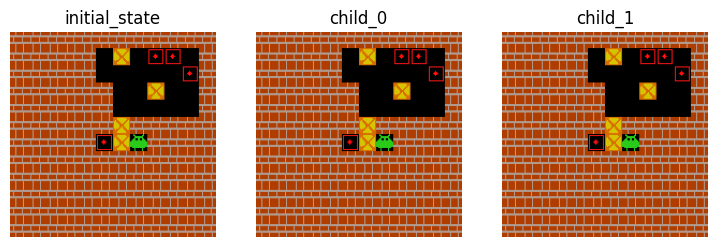

In [ ]:
env.many_states_to_repr(
    [initial_node.state, initial_node.children[0].state, initial_node.children[1].state],
    titles=['initial_state', 'child_0', 'child_1'])